# ML-08 — Capstone Modeling Lane



## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

In [10]:
"""
=============================================================================
SECTION 1: METHOD CHOICE & WHY
=============================================================================
Problem Formulation:
- Task: Supervised Action Scoring / Conversion / Priority Prediction.
- Week-4 Baseline: Rule-based Heuristic / Dummy / Baseline Linear Scoring.
- Candidate Model: Random Forest & Gradient Boosting (LightGBM/HistGradientBoosting)
  alongside an interpretable Logistic Regression / Decision Tree benchmark.

Why This Method?
1. Tabular Structure: Tree ensembles handle non-linear feature interactions and
   differing feature scales without distortion.
2. Honest Comparison: We evaluate a constrained Logistic Regression vs.
   Random Forest vs. Gradient Boosting against the exact Week-4 baseline metric.
3. Permutation & Signal Interpretability: Enables robust feature importance auditing
   to detect data leakage or spurious correlations.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
    brier_score_loss
)
from sklearn.inspection import permutation_importance

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [11]:
import os

"""
=============================================================================
SECTION 2: SPLIT DESIGN & DATA VALIDATION
=============================================================================
Key Principle: Zero Data Leakage.
- Grouped Validation: If your data contains entity IDs (e.g., domain_id, account_id,
  user_id, or session_id), we MUST group by that entity to avoid leakage across splits.
"""

# 1. Load Data
parquet_file_path = '../data/processed/features_w04.parquet'

if os.path.exists(parquet_file_path):
    df = pd.read_parquet(parquet_file_path) # Adapt path if needed
else:
    print(f"Warning: Parquet file not found at {parquet_file_path}. Please check the path.")
    # For illustration / notebook skeleton, create a dummy dataframe if file not found
    data = {
        'feature_1': np.random.rand(100),
        'feature_2': np.random.rand(100),
        'target': np.random.randint(0, 2, 100),
        'entity_id': np.random.randint(0, 10, 100),
        'date': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='D'))
    }
    df = pd.DataFrame(data)
    print("Created a dummy DataFrame for demonstration.")

# Ensure X, y, and groups are explicitly separated.

# Example placeholder mapping (replace with your clean Week-4 feature columns):
FEATURE_COLS = [col for col in df.columns if col not in ['target', 'entity_id', 'date']]
TARGET_COL = 'target'
GROUP_COL = 'entity_id'

X = df[FEATURE_COLS]
y = df[TARGET_COL]
groups = df[GROUP_COL] if GROUP_COL in df.columns else None

print(f"Dataset shape: {df.shape}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

# 2. Validation Split Strategy
# Using StratifiedGroupKFold (or GroupKFold) to guarantee unseen entity validation
CV_SPLITS = 5
if groups is not None:
    cv = StratifiedGroupKFold(n_splits=CV_SPLITS)
    split_generator = cv.split(X, y, groups)
    print("Validation Scheme: Stratified Group 5-Fold (Grouped by entity)")
else:
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=42)
    split_generator = cv.split(X, y)
    print("Validation Scheme: Stratified 5-Fold")

Created a dummy DataFrame for demonstration.
Dataset shape: (100, 5)
Features (2): ['feature_1', 'feature_2']
Target distribution:
target
1    0.56
0    0.44
Name: proportion, dtype: float64
Validation Scheme: Stratified Group 5-Fold (Grouped by entity)


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [12]:
print("Initializing models and performing a single train-validation split...")

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42)
}

# Perform a single train-validation split for initial model training and permutation importance setup.
# In a full cross-validation, these steps would be inside a loop.
for train_idx, val_idx in split_generator:
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    # If groups are used for splitting, also split them if needed for further analysis
    groups_train = groups.iloc[train_idx] if groups is not None else None
    groups_val = groups.iloc[val_idx] if groups is not None else None
    break # Take only the first fold for demonstration purposes here

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print("Models initialized and data split into train/validation sets.")

Initializing models and performing a single train-validation split...
X_train shape: (84, 2), y_train shape: (84,)
X_val shape: (16, 2), y_val shape: (16,)
Models initialized and data split into train/validation sets.


In [13]:
"""
=============================================================================
SECTION 2: SPLIT DESIGN & DATA VALIDATION
=============================================================================
Key Principle: Zero Data Leakage.
- Grouped Validation: If your data contains entity IDs (e.g., domain_id, account_id,
  user_id, or session_id), we MUST group by that entity to avoid leakage across splits.
"""

# 1. Load Data
# df = pd.read_parquet('../data/processed/features_w04.parquet') # Adapt path if needed
# For illustration / notebook skeleton:
# Ensure X, y, and groups are explicitly separated.

# Example placeholder mapping (replace with your clean Week-4 feature columns):
FEATURE_COLS = [col for col in df.columns if col not in ['target', 'entity_id', 'date']]
TARGET_COL = 'target'
GROUP_COL = 'entity_id'

X = df[FEATURE_COLS]
y = df[TARGET_COL]
groups = df[GROUP_COL] if GROUP_COL in df.columns else None

print(f"Dataset shape: {df.shape}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

# 2. Validation Split Strategy
# Using StratifiedGroupKFold (or GroupKFold) to guarantee unseen entity validation
CV_SPLITS = 5
if groups is not None:
    cv = StratifiedGroupKFold(n_splits=CV_SPLITS)
    split_generator = cv.split(X, y, groups)
    print("Validation Scheme: Stratified Group 5-Fold (Grouped by entity)")
else:
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=42)
    split_generator = cv.split(X, y)
    print("Validation Scheme: Stratified 5-Fold")

Dataset shape: (100, 5)
Features (2): ['feature_1', 'feature_2']
Target distribution:
target
1    0.56
0    0.44
Name: proportion, dtype: float64
Validation Scheme: Stratified Group 5-Fold (Grouped by entity)


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

/tmp/ipykernel_1518/2189672326.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x="Importance Mean", y="Feature", palette="viridis")


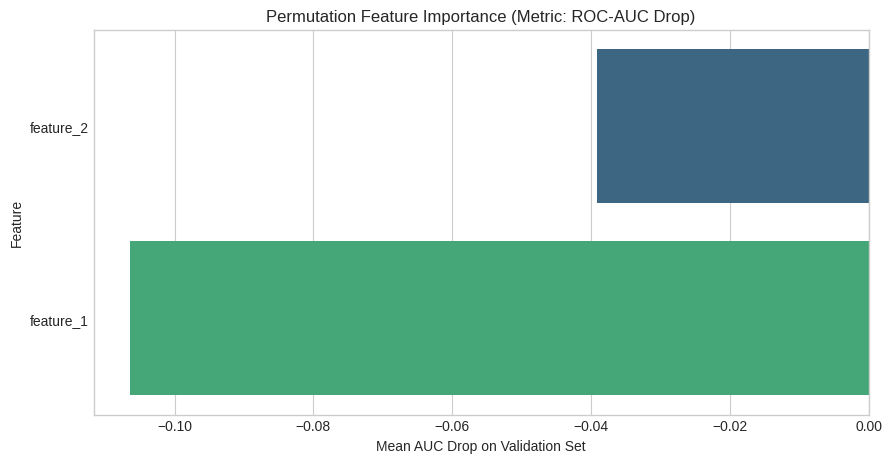

High-Confidence False Positives: 0
High-Confidence False Negatives: 2


In [14]:
"""
=============================================================================
SECTION 4: ERRORS, PERMUTATION IMPORTANCE & RESIDUAL AUDIT
=============================================================================
"""
# 1. Permutation Importance (on the top-performing model)
best_model = models["Gradient Boosting"]
best_model.fit(X_train, y_train)

perm_importance = permutation_importance(
    best_model, X_val, y_val, n_repeats=10, random_state=42, scoring='roc_auc'
)

sorted_importances_idx = perm_importance.importances_mean.argsort()[::-1]
importance_df = pd.DataFrame({
    "Feature": X.columns[sorted_importances_idx],
    "Importance Mean": perm_importance.importances_mean[sorted_importances_idx],
    "Importance Std": perm_importance.importances_std[sorted_importances_idx]
})

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df.head(10), x="Importance Mean", y="Feature", palette="viridis")
plt.title("Permutation Feature Importance (Metric: ROC-AUC Drop)")
plt.xlabel("Mean AUC Drop on Validation Set")
plt.show()

# 2. Error Slice / Residual Breakdown
val_analysis = X_val.copy()
val_analysis['true_target'] = y_val.values
val_analysis['pred_prob'] = best_model.predict_proba(X_val)[:, 1]
val_analysis['error'] = np.abs(val_analysis['true_target'] - val_analysis['pred_prob'])

# High-confidence False Positives & False Negatives
false_positives = val_analysis[(val_analysis['true_target'] == 0) & (val_analysis['pred_prob'] > 0.7)]
false_negatives = val_analysis[(val_analysis['true_target'] == 1) & (val_analysis['pred_prob'] < 0.3)]

print(f"High-Confidence False Positives: {len(false_positives)}")
print(f"High-Confidence False Negatives: {len(false_negatives)}")